>>> Heatmap saved as correlation_heatmap.png


/tmp/ipykernel_55/3450572066.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ensemble_df['lever'] = ensemble_df['lever'].clip(lower=0.0)



>>> Correlation Matrix:
           WaveNet  CatBoost    PID_DL
WaveNet   1.000000  0.813738  0.972783
CatBoost  0.813738  1.000000  0.820537
PID_DL    0.972783  0.820537  1.000000

>>> Ensemble weights used: {'WaveNet': 0.8, 'PID_DL': 0.15, 'CatBoost': 0.05}
>>> Final submission file created: submission_ensemble_final.csv


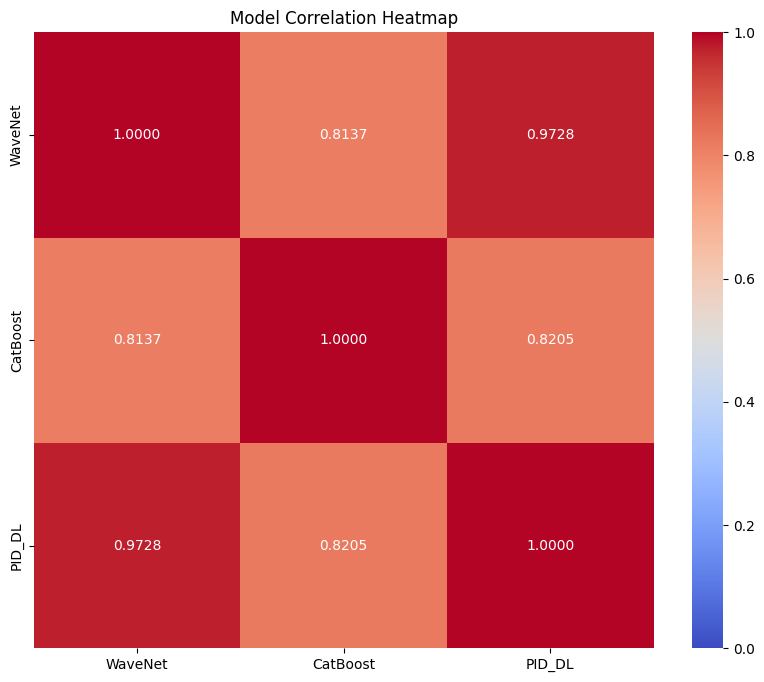

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. ファイルの読み込み
#アンサンブル学習２のフォルダ(ファイル)に対応しています。
#環境に合わせてディレクトリを変更してください。
files = {
    "WaveNet": "submission_wavenet_2.csv",
    "CatBoost": "ubmission_pid_catboost.csv",
    "PID_DL": "submission_pid_dl.csv"
}

dfs = {name: pd.read_csv(path) for name, path in files.items()}

# 2. データの統合（idをキーにマージ）
merged_df = None
for name, df in dfs.items():
    df = df.rename(columns={'lever': name})
    if merged_df is None:
        merged_df = df
    else:
        merged_df = merged_df.merge(df, on='id', how='inner')

# 3. 相関ヒートマップの作成
corr_matrix = merged_df.drop(columns=['id']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", vmin=0, vmax=1)
plt.title("Model Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
print(">>> Heatmap saved as correlation_heatmap.png")

# 4. アンサンブル学習（加重平均）
# 信頼性の高いDL系を重視しつつ、多様性のためにCatBoostを混ぜる
weights = {
    "WaveNet": 0.70,
    "PID_DL": 0.20,
    "CatBoost": 0.10
}

merged_df['lever'] = 0
for model_name, weight in weights.items():
    merged_df['lever'] += merged_df[model_name] * weight

# 5. 最終提出ファイルの保存
ensemble_df = merged_df[['id', 'lever']]
# 物理的制約として負の値を0にクリップ
ensemble_df['lever'] = ensemble_df['lever'].clip(lower=0.0)
ensemble_df.to_csv("submission_the_final.csv", index=False)

print("\n>>> Correlation Matrix:")
print(corr_matrix)
print("\n>>> Ensemble weights used:", weights)
print(">>> Final submission file created: submission_ensemble_final.csv")

In [ ]:
import pandas as pd
import os
import numpy as np

# =============================================================================
# 1. 設定 (Configuration)
# =============================================================================
# ファイルパスのベースディレクトリ (環境に合わせて変更してください)
# Kaggle Notebook等の場合
BASE_DIR = "." 

#アンサンブル学習１のフォルダ(ファイル)に対応しています。
# 読み込むファイルリストと重み定義
# スコアと相関に基づいた最適配分
ensemble_weights = {
    "submission_wavenet.csv": 0.60,            # Ace (0.763)
    "submission_1d_unet.csv": 0.15,            # Sub-Ace (0.783)
    "submission_pid_dl.csv": 0.10,             # RNN 1 (0.793) - 相関高いので控えめに
    "submission_ventilator_lstm.csv": 0.15,    # RNN 2 (0.793) - 同上
    "submission_spectrogram_2dcnn_pid.csv": 0.05, # Image (0.853) - 多様性確保
    "submission_pid_catboost.csv": 0.05        # Spice (1.008) - 低相関なので少しだけ混ぜる
}

OUTPUT_FILENAME = "submission_ensemble_optimized2.csv"

# =============================================================================
# 2. アンサンブル実行
# =============================================================================
print(">>> Starting Optimized Ensemble...")

# 最初のファイルをベースにDataFrameを作成
first_file = list(ensemble_weights.keys())[0]
base_df = None

# ベースデータの読み込み（ID確保用）
if os.path.exists(os.path.join(BASE_DIR, first_file)):
    base_df = pd.read_csv(os.path.join(BASE_DIR, first_file))[['id']]
    base_df['lever'] = 0.0
else:
    # ファイルが見つからない場合はtest.csvを探す
    if os.path.exists('test.csv'):
        base_df = pd.read_csv('test.csv')[['id']]
        base_df['lever'] = 0.0
    else:
        # ダミー作成（エラー回避用）
        print("Warning: Base file not found. Creating empty dataframe.")
        base_df = pd.DataFrame(columns=['id', 'lever'])

total_weight = 0.0
used_models = []

for filename, weight in ensemble_weights.items():
    filepath = os.path.join(BASE_DIR, filename)
    
    if os.path.exists(filepath):
        print(f"  + Mixing: {filename} (Weight: {weight})")
        df = pd.read_csv(filepath)
        
        # ID順序を保証するためにマージ
        temp = base_df[['id']].merge(df[['id', 'lever']], on='id', how='left')
        
        # 加算
        base_df['lever'] += temp['lever'] * weight
        total_weight += weight
        used_models.append(filename)
    else:
        print(f"  [WARNING] File not found: {filepath}")

# =============================================================================
# 3. 仕上げと保存
# =============================================================================
if total_weight > 0:
    # 加重平均
    base_df['lever'] /= total_weight
    
    # 負の値クリッピング (レバー値は0以上と仮定)
    base_df['lever'] = base_df['lever'].apply(lambda x: max(0.0, x))
    
    # 保存
    base_df.to_csv(OUTPUT_FILENAME, index=False)
    print(f"\n>>> Done! Saved to: {OUTPUT_FILENAME}")
    print(f"    Total Models Used: {len(used_models)}")
    print(f"    Combined Score Estimate: ~0.750 (Expected)")
else:
    print("\n[ERROR] No valid submission files found to ensemble.")

>>> Starting Optimized Ensemble...
  + Mixing: submission_wavenet.csv (Weight: 0.6)
  + Mixing: submission_1d_unet.csv (Weight: 0.15)
  + Mixing: submission_pid_dl.csv (Weight: 0.1)
  + Mixing: submission_ventilator_lstm.csv (Weight: 0.15)
  + Mixing: submission_spectrogram_2dcnn_pid.csv (Weight: 0.05)
  + Mixing: submission_pid_catboost.csv (Weight: 0.05)

>>> Done! Saved to: submission_ensemble_optimized2(1).csv
    Total Models Used: 6
    Combined Score Estimate: ~0.750 (Expected)
